### <strong> Insurance Cost Prediction with Linear Regression</strong>
### Project Workflow

This notebook follows a structured approach to predict medical insurance costs using linear regression:

1. **Import necessary libraries**: Load libraries for data handling, visualization, and modeling.
2. **Data wrangling and loading**: Clean and prepare the dataset.
3. **Exploratory Data Analysis (EDA)**: Visualize distributions, relationships, and correlations.
4. **Feature and target selection**: Define predictors and target variable.
5. **Train-test split**: Divide data into training and testing sets.
6. **Baseline model evaluation**: Establish a baseline using mean prediction.
7. **Build and train the linear regression model**: Create and fit the model pipeline.
8. **Evaluate model performance**: Assess accuracy on training and test sets.
9. **Analyze feature importances**: Interpret which features influence predictions most.

<strong>Import Libraries</strong>

In [ ]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error
from category_encoders import OneHotEncoder
from sklearn.impute import SimpleImputer 
from sklearn.pipeline import make_pipeline

<strong>File Wrangling</strong>

In [ ]:
# Define a function to wrangle the data: load CSV, round charges, and rename the target column
def wrangle(filepath): 
    df = pd.read_csv(filepath)
    df['charges'] = round(df['charges'], 2)
    df.rename(columns={'charges':'charges ($)'}, inplace=True)

    return df

<strong>Import File</strong>

In [ ]:
# Load the dataset using the wrangle function and display the first 5 rows
insurance_df = wrangle("insurance.csv")
insurance_df.head(5)

,age,sex,bmi,children,smoker,region,charges ($)
0,19,female,27.900,0,yes,southwest,16884.92
1,18,male,33.770,1,no,southeast,1725.55
2,28,male,33.000,3,no,southeast,4449.46
3,33,male,22.705,0,no,northwest,21984.47
4,32,male,28.880,0,no,northwest,3866.86


<strong>Data Exploration</strong>

In [ ]:
# Display dataset information and summary statistics to understand the data structure and distributions
print(insurance_df.info())
print(insurance_df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1338 non-null   int64  
 1   sex          1338 non-null   str    
 2   bmi          1338 non-null   float64
 3   children     1338 non-null   int64  
 4   smoker       1338 non-null   str    
 5   region       1338 non-null   str    
 6   charges ($)  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None
               age          bmi     children   charges ($)
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422280
std      14.049960     6.098187     1.205493  12110.011259
min      18.000000    15.960000     0.000000   1121.870000
25%      27.000000    26.296250     0.000000   4740.287500
50%      39.000000    30.400000     1.000000   9382.030000
75%      51.000000    34.693750     2.000000  1663

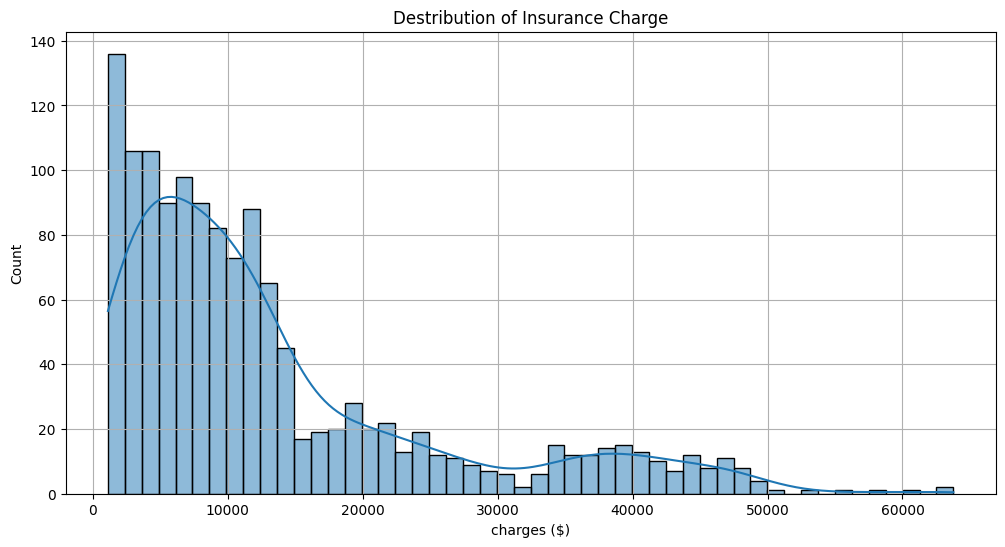

In [ ]:
# Visualize the distribution of insurance charges using a histogram with KDE
plt.figure(figsize=(12, 6))
sns.histplot(insurance_df['charges ($)'], bins=50, kde=True)
plt.title("Destribution of Insurance Charge")
plt.grid(True);

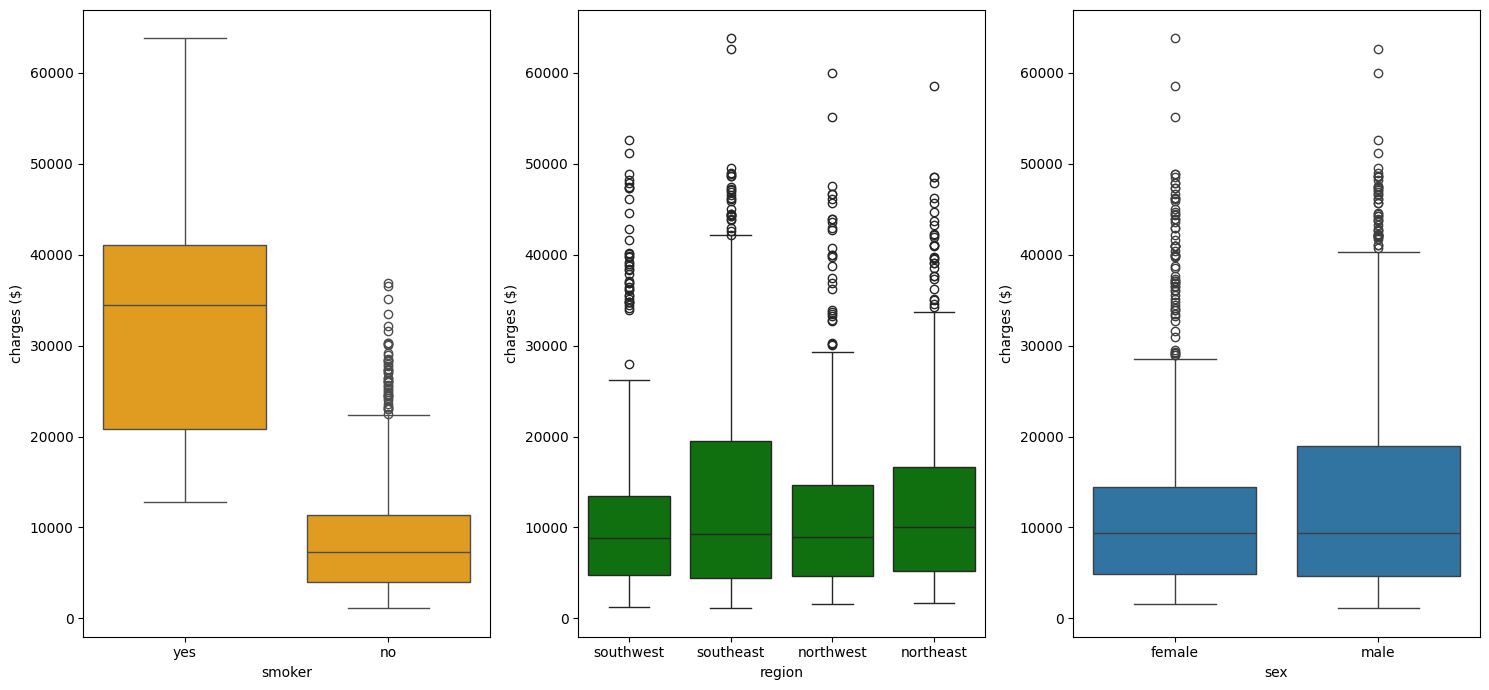

In [ ]:
# Create box plots to compare charges across categorical variables: smoker, region, and sex
fig, axes = plt.subplots(1, 3, figsize=(15, 7))
sns.boxplot(x='smoker', y='charges ($)', data=insurance_df, ax=axes[0], color='orange')
sns.boxplot(x='region', y='charges ($)', data=insurance_df, ax=axes[1], color='green')
sns.boxplot(x='sex', y='charges ($)', data=insurance_df, ax=axes[2])
plt.tight_layout()
plt.show()

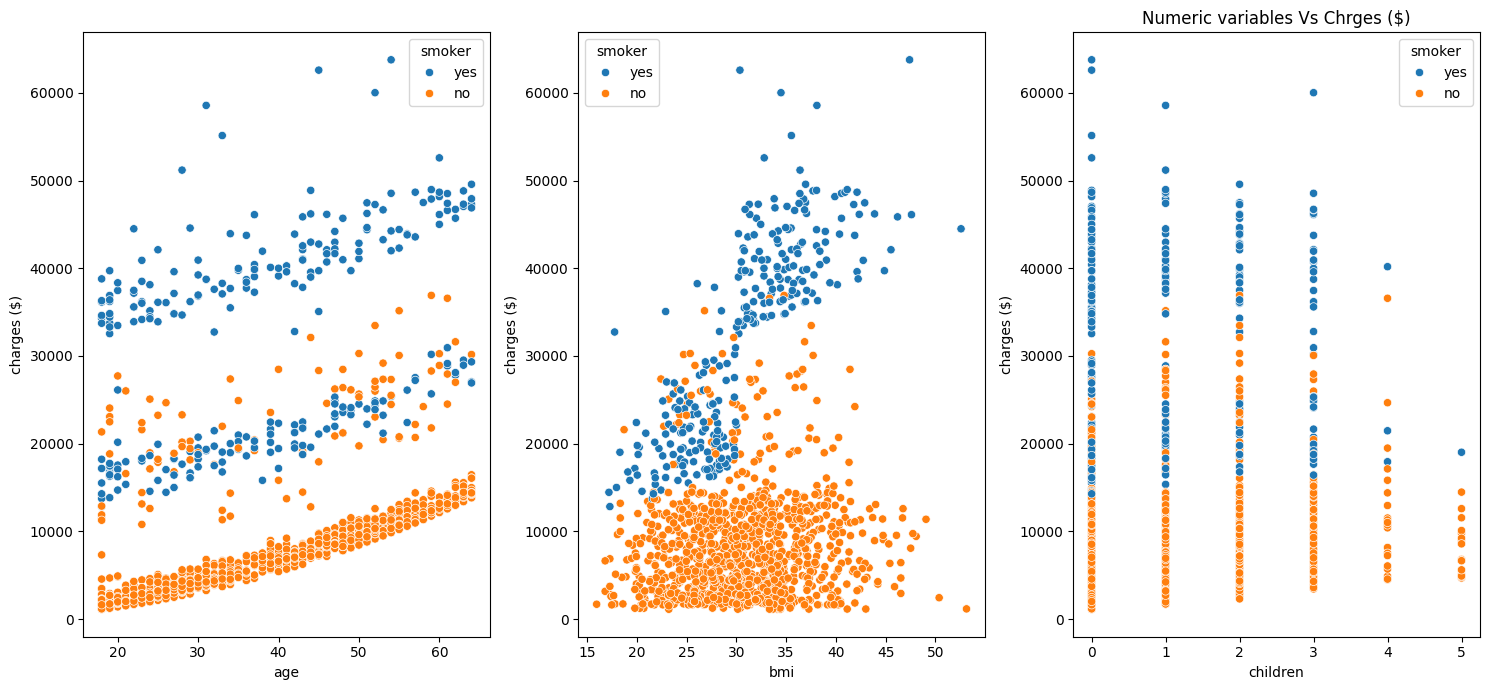

In [ ]:
# Scatter plots to examine relationships between numerical variables (age, bmi, children) and charges, colored by smoker status
fig, axes= plt.subplots(1, 3, figsize=(15, 7))
sns.scatterplot(x='age', y='charges ($)', data=insurance_df, hue='smoker', ax=axes[0])
sns.scatterplot(x='bmi', y='charges ($)', data=insurance_df, hue='smoker', ax=axes[1])
sns.scatterplot(x='children', y='charges ($)', data=insurance_df, hue='smoker', ax=axes[2])
plt.title('Numeric variables Vs Chrges ($)')
plt.tight_layout()
plt.show();

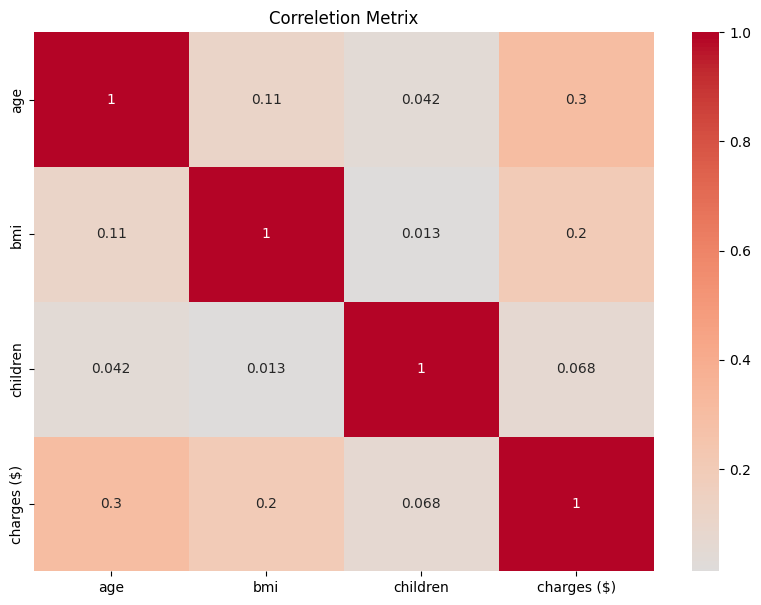

In [ ]:
# Compute and visualize the correlation matrix for numerical features to identify relationships
numeric_df = insurance_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correletion Metrix')
plt.show()

<strong>SPLIT</strong>

In [ ]:
# Select all features except the target variable for modeling
features = insurance_df.drop(columns=['charges ($)']).columns
target = 'charges ($)'
X = insurance_df[features]
y = insurance_df[target]
print(X.shape)
print(y.shape)

(1338, 6)
(1338,)


In [ ]:
# Split the data into training (80%) and testing (20%) sets
cutoff = int(len(y) * 0.8)

X_train, y_train = X.iloc[:cutoff], y.iloc[:cutoff]
X_test, y_test = X.iloc[cutoff:], y.iloc[cutoff:]

<strong>Baseline</strong>

In [90]:
# Calculate baseline MAE by predicting the training set mean for all observations
y_mean = y_train.mean()
baseline_pred = [y_mean] * len(y_train)
baaseline_mae = mean_absolute_error(y_train, baseline_pred)
print(f'y_mean: {y_mean:.2f}')
print(f"Baseline MAE: {baaseline_mae:.2f}")

y_mean: 13214.13
Baseline MAE: 9038.35


In [ ]:
# Fit OneHotEncoder on training data to transform categorical variables
ohe = OneHotEncoder(use_cat_names=True)
ohe.fit(X_train)

XT_train = ohe.transform(X_train)
print(XT_train)

      age  sex_female  sex_male     bmi  children  smoker_yes  smoker_no  \
0      19           1         0  27.900         0           1          0   
1      18           0         1  33.770         1           0          1   
2      28           0         1  33.000         3           0          1   
3      33           0         1  22.705         0           0          1   
4      32           0         1  28.880         0           0          1   
...   ...         ...       ...     ...       ...         ...        ...   
1065   42           1         0  25.300         1           0          1   
1066   48           0         1  37.290         2           0          1   
1067   39           0         1  42.655         0           0          1   
1068   63           0         1  21.660         1           0          1   
1069   54           1         0  31.900         1           0          1   

      region_southwest  region_southeast  region_northwest  region_northeast  
0       

<strong>Itrate</strong>

In [ ]:
# Create and fit a pipeline with OneHotEncoder and LinearRegression
model = make_pipeline(
    OneHotEncoder(use_cat_names=True, drop_invariant=True),
    LinearRegression()
)
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('onehotencoder', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,verbose,0
,cols,"['sex', 'smoker', ...]"
,drop_invariant,True
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,True


In [91]:
# Predict on training data and calculate MAE
y_pred_training = model.predict(X_train)
train_mae = mean_absolute_error(y_train, y_pred_training)
print(f"MAE_of_trained_y: {train_mae:.2f}")

MAE_of_trained_y: 4151.56


<strong>Evaluate</strong>

In [92]:
# Predict on test data and calculate MAE
y_pred_test = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
print(f"MAE_of_tested_y: {test_mae:.2f}")

MAE_of_tested_y: 4225.23


In [93]:
# Extract coefficients and feature names to analyze feature importance
coefficient = model.named_steps['linearregression'].coef_
feature_names = model.named_steps['onehotencoder'].get_feature_names_out()
feat_imp = pd.Series(coefficient, index=feature_names)
feat_imp[feat_imp.abs().sort_values(ascending=True).index]

sex_male             -126.901013
sex_female            126.901013
region_northwest      237.552837
age                   259.490280
bmi                   339.188963
region_southeast     -410.067810
children              439.167735
region_southwest     -536.705490
region_northeast      709.220463
smoker_no          -11826.716726
smoker_yes          11826.716726
dtype: float64

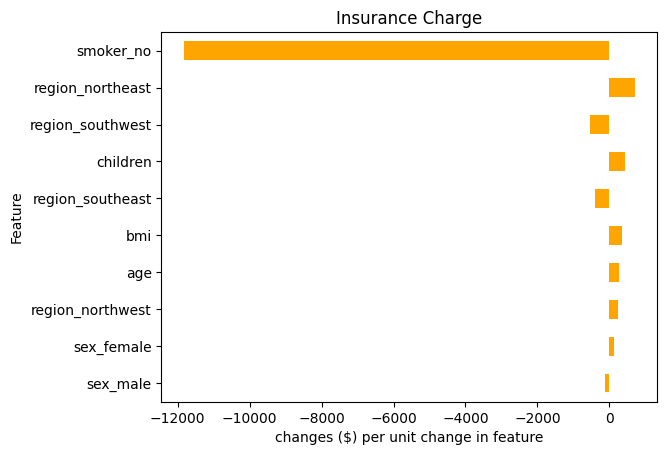

In [96]:
# Visualize feature importances with a horizontal bar plot
fig, ax = plt.subplots()

# Create the horizontal bar plot on the axes object
feat_imp.sort_values(key=abs).head(10).plot(kind='barh', ax=ax, color='orange')

#  Label axes 
plt.xlabel("changes ($) per unit change in feature") 
plt.ylabel('Feature')

# Add title 
plt.title("Insurance Charge");